<a href="https://colab.research.google.com/github/rozaxa/Artificial-Intelligence-Workshop-II/blob/optimizer_comparison/optimization_improvements_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 5.0 MB/s eta 0:00:00


In [ ]:
pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 58.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.0
    Uninstalling scikit-learn-1.6.0:
      Successfully uninstalled scikit-learn-1.6.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV
import optuna
import time
import matplotlib.pyplot as plt


from sklearn.model_selection import cross_val_score
import category_encoders as ce



# **Regression problem**


In [ ]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

X = pd.DataFrame(data, columns=[
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
])
y = pd.Series(target, name="MEDV")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Random forest regressor

start_time_RF = time.time()

baseline_model = RandomForestRegressor(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
baseline_time_RF = time.time() - start_time_RF

print("Radom forest Regression RMSE:", baseline_rmse)
print("Radom forest Regression time", baseline_time_RF, "seconds")



Radom forest Regression RMSE: 2.8109631609391226
Radom forest Regression time 0.5892074108123779 seconds


In [ ]:
#GridSearchCV

start_time_GridSearchCV = time.time()


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

time_GridSearchCV = time.time() - start_time_GridSearchCV

Fitting 3 folds for each of 36 candidates, totalling 108 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
best_grid_params = grid_search.best_params_
best_grid_model = RandomForestRegressor(
    n_estimators=best_grid_params["n_estimators"],
    max_depth=best_grid_params["max_depth"],
    min_samples_split=best_grid_params["min_samples_split"],
    min_samples_leaf=best_grid_params["min_samples_leaf"],
    random_state=42
)


In [ ]:
best_grid_model.fit(X_train, y_train)
y_pred_grid = best_grid_model.predict(X_test)
grid_rmse = np.sqrt(mean_squared_error(y_test, y_pred_grid))
print("GridSearchCV Optimized Regression RMSE:", grid_rmse)
print("Time GridSearchCV:", time_GridSearchCV, "seconds")


GridSearchCV Optimized Regression RMSE: 2.724436890396961
Time GridSearchCV: 52.47557759284973 seconds


In [ ]:
#Optuna

def objective_regression(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    reg_model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))



In [ ]:
start_time_Optuna = time.time()


study = optuna.create_study(direction="minimize")
study.optimize(objective_regression, n_trials=100)

time_Optuna = time.time() - start_time_Optuna


best_params = study.best_params


[I 2025-01-12 11:36:40,960] A new study created in memory with name: no-name-9ff17355-cb4f-43b7-a366-b926d99c25df
[I 2025-01-12 11:36:41,930] Trial 0 finished with value: 3.008836255562539 and parameters: {'n_estimators': 175, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: 3.008836255562539.
[I 2025-01-12 11:36:42,918] Trial 1 finished with value: 3.3477934823127415 and parameters: {'n_estimators': 296, 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 3.008836255562539.
[I 2025-01-12 11:36:43,414] Trial 2 finished with value: 3.975675256393807 and parameters: {'n_estimators': 239, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 0 with value: 3.008836255562539.
[I 2025-01-12 11:36:44,186] Trial 3 finished with value: 3.5010832385064097 and parameters: {'n_estimators': 255, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 0 with value: 3.0088

In [ ]:
best_params = study.best_params
optimized_model = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42
)
optimized_model.fit(X_train, y_train)
y_pred_optimized = optimized_model.predict(X_test)
optimized_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
print("Optuna Optimized Regression RMSE:", optimized_rmse)
print("Time Optituna:", time_Optuna, "seconds")

Optuna Optimized Regression RMSE: 2.664431318368099
Time Optituna: 46.77307105064392 seconds


In [ ]:
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_parallel_coordinate(study)


In [ ]:
trials_df = study.trials_dataframe()

# print(trials_df)


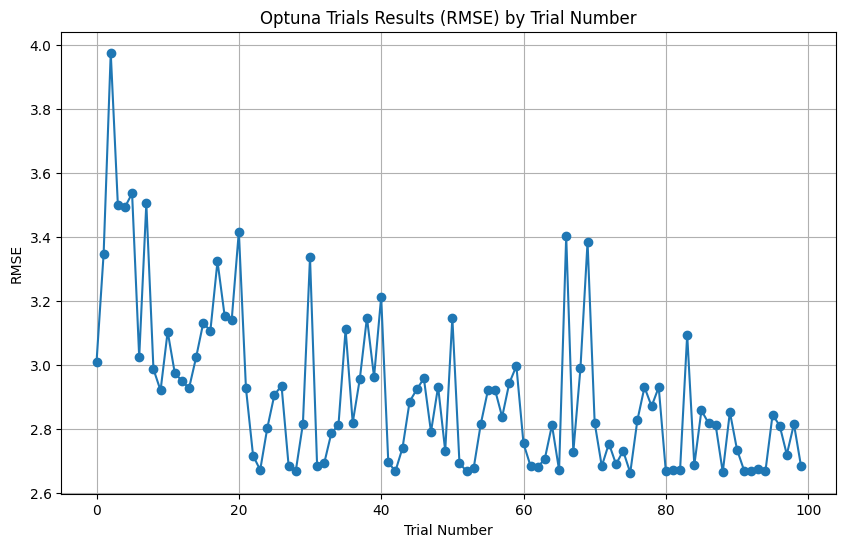

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-')
plt.title('Optuna Trials Results (RMSE) by Trial Number')
plt.xlabel('Trial Number')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


In [ ]:
print("Baseline Regression RMSE:", baseline_rmse)
print("GridSearchCV Optimized Regression RMSE:", grid_rmse)
print("Optuna Optimized Regression RMSE:", optimized_rmse)

Baseline Regression RMSE: 2.8109631609391226
GridSearchCV Optimized Regression RMSE: 2.724436890396961
Optuna Optimized Regression RMSE: 2.664431318368099


### Optimizers comparison for regression porblems


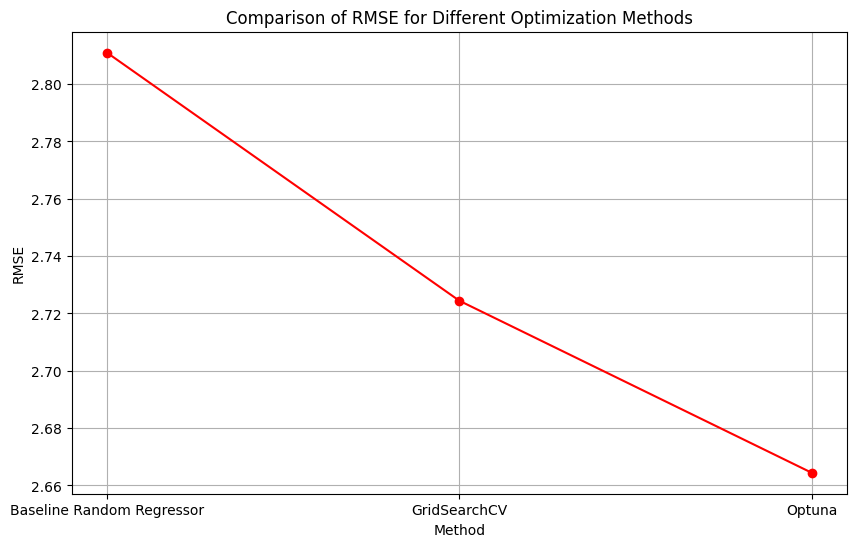

In [ ]:
model_names = ['Baseline Random Regressor', 'GridSearchCV', 'Optuna']
rmse_values = [baseline_rmse, grid_rmse, optimized_rmse]

plt.figure(figsize=(10, 6))
plt.plot(model_names, rmse_values, marker='o', linestyle='-', color='red')
plt.title('Comparison of RMSE for Different Optimization Methods')
plt.xlabel('Method')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()


In [ ]:
execution_times = [baseline_time_RF, time_GridSearchCV, time_Optuna]
model_names = ['Baseline', 'GridSearchCV', 'Optuna']

plt.figure(figsize=(10, 6))
plt.plot(model_names, execution_times, marker='o', linestyle='-', color='blue')
plt.title('Comparison of time for Different Optimization Methods')
plt.xlabel('Method')
plt.ylabel('Time')
plt.grid(True)
plt.show()



In [ ]:
improvement_grid = baseline_rmse - grid_rmse
improvement_optuna = baseline_rmse - optimized_rmse
print("Improvement over Baseline (RMSE difference):")
print("GridSearchCV:", improvement_grid)
print("Optuna:", improvement_optuna)

Improvement over Baseline (RMSE difference):
GridSearchCV: 0.08652627054216167
Optuna: 0.14653184257102359


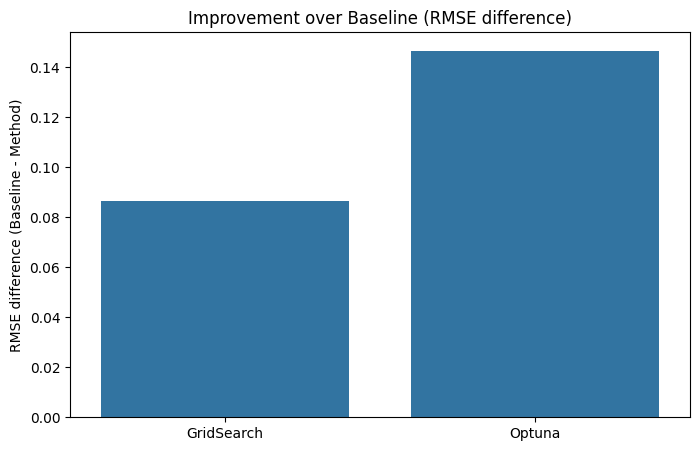

In [ ]:
import seaborn as sns

improvement_values = [improvement_grid, improvement_optuna]
methods = [ 'GridSearch', 'Optuna']

plt.figure(figsize=(8,5))
sns.barplot(x=methods, y=improvement_values)
plt.title("Improvement over Baseline (RMSE difference)")
plt.ylabel("RMSE difference (Baseline - Method)")
plt.show()


In [ ]:
results_df = pd.DataFrame({
    "Method": ["Baseline", "GridSearch", "Optuna"],
    "Model": ["RandomForestRegressor"] * 3,
    "Time": [baseline_time_RF, time_GridSearchCV, time_Optuna],
    "RMSE": [baseline_rmse, grid_rmse, optimized_rmse],
    "Best Params (GridSearch)": [np.nan, str(best_grid_params), np.nan],
    "Best Params (Optuna)": [np.nan, np.nan, str(best_params)]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

print("\n=== Results DataFrame ===")
print(results_df[["Method", "Model", "Time", "RMSE"]])


print(" ")
print(results_df[["Best Params (GridSearch)"]])


print(" ")
print(results_df[["Best Params (Optuna)"]])


=== Results DataFrame ===
       Method                  Model       Time      RMSE
0    Baseline  RandomForestRegressor   0.589207  2.810963
1  GridSearch  RandomForestRegressor  52.475578  2.724437
2      Optuna  RandomForestRegressor  46.773071  2.664431
 
                                                               Best Params (GridSearch)
0                                                                                   NaN
1  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
2                                                                                   NaN
 
                                                                   Best Params (Optuna)
0                                                                                   NaN
1                                                                                   NaN
2  {'n_estimators': 64, 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 1}


# **Classification problem**

In [49]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]
data = pd.read_csv(url, header=None, names=columns, na_values="?")
data.dropna(inplace=True)



In [50]:
label_enc = LabelEncoder()
data["income"] = label_enc.fit_transform(data["income"])
X = pd.get_dummies(data.drop("income", axis=1), drop_first=True)
y = data["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
start_time = time.time()
default_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
default_model.fit(X_train, y_train)
default_duration = time.time() - start_time

In [52]:
y_pred_default = default_model.predict(X_test)
default_accuracy = accuracy_score(y_test, y_pred_default)
print("Default accurancy:", default_accuracy)
print("Default model duration:", default_duration, "seconds")

Default accurancy: 0.8582834331337326
Default model duration: 18.535615921020508 seconds


In [53]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
grid_duration = time.time() - start_time
best_grid_params = grid_search.best_params_
print("Best GridSearchCV parameters:", best_grid_params)
print("GridSearchCV duration:", grid_duration, "seconds")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best GridSearchCV parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
GridSearchCV duration: 548.8360140323639 seconds


In [54]:
best_grid_model = RandomForestClassifier(**best_grid_params, random_state=42)
best_grid_model.fit(X_train, y_train)
y_pred_grid = best_grid_model.predict(X_test)
grid_accuracy = accuracy_score(y_test, y_pred_grid)
print("GridSearchCV Optimized accuracy:", grid_accuracy)

GridSearchCV Optimized accuracy: 0.8668816213726394


In [55]:
start_time = time.time()
def objective_classification(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective_classification, n_trials=150)
optuna_duration = time.time() - start_time

best_optuna_params = study.best_params
print("Best Optuna parameters:", best_optuna_params)
print("Optuna duration:", optuna_duration, "seconds")


optimized_model = RandomForestClassifier(
    n_estimators=best_optuna_params["n_estimators"],
    max_depth=best_optuna_params["max_depth"],
    min_samples_split=best_optuna_params["min_samples_split"],
    min_samples_leaf=best_optuna_params["min_samples_leaf"],
    random_state=42
)
optimized_model.fit(X_train, y_train)
y_pred_optimized = optimized_model.predict(X_test)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)

print("Optuna Optimized accuracy:", optimized_accuracy)

[I 2025-01-12 17:09:22,833] A new study created in memory with name: no-name-f80ad8e4-3800-47e8-846b-34f73a86759d
[I 2025-01-12 17:09:52,197] Trial 0 finished with value: 0.8600662002019981 and parameters: {'n_estimators': 218, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8600662002019981.
[I 2025-01-12 17:10:11,605] Trial 1 finished with value: 0.8603734566889065 and parameters: {'n_estimators': 153, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.8603734566889065.
[I 2025-01-12 17:10:33,509] Trial 2 finished with value: 0.8641741427154905 and parameters: {'n_estimators': 142, 'max_depth': 29, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.8641741427154905.
[I 2025-01-12 17:10:40,016] Trial 3 finished with value: 0.8385291587091441 and parameters: {'n_estimators': 93, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 2 with value: 

Best Optuna parameters: {'n_estimators': 142, 'max_depth': 29, 'min_samples_split': 9, 'min_samples_leaf': 2}
Optuna duration: 5076.235050678253 seconds
Optuna Optimized accuracy: 0.8687240902809765


In [56]:
print("Default accuracy:", default_accuracy)
print("GridSearchCV Optimized accuracy:", grid_accuracy)
print("Optuna Optimized accuracy:", optimized_accuracy)

Default accuracy: 0.8582834331337326
GridSearchCV Optimized accuracy: 0.8668816213726394
Optuna Optimized accuracy: 0.8687240902809765


### Optimizer comparison for classification problem





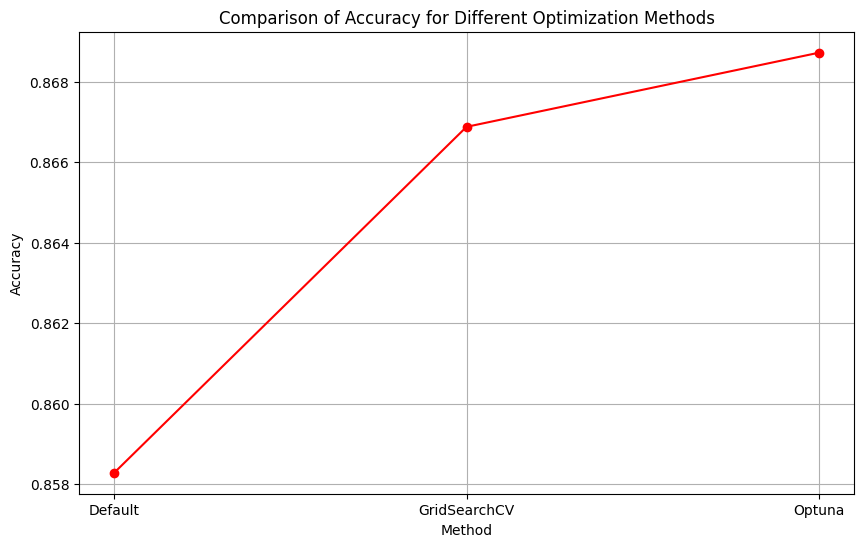

In [57]:
model_names = ["Default", "GridSearchCV", "Optuna"]
accuracies = [default_accuracy, grid_accuracy, optimized_accuracy]
execution_times = [default_duration, grid_duration, optuna_duration]

plt.figure(figsize=(10, 6))
plt.plot(model_names, accuracies, marker='o', linestyle='-', color='red')
plt.title('Comparison of Accuracy for Different Optimization Methods')
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


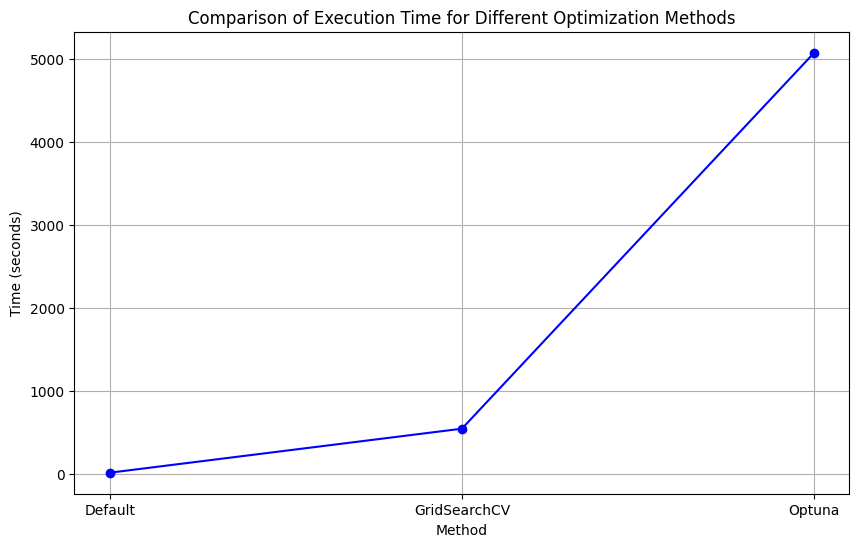

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(model_names, execution_times, marker='o', linestyle='-', color='blue')
plt.title('Comparison of Execution Time for Different Optimization Methods')
plt.xlabel('Method')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.show()


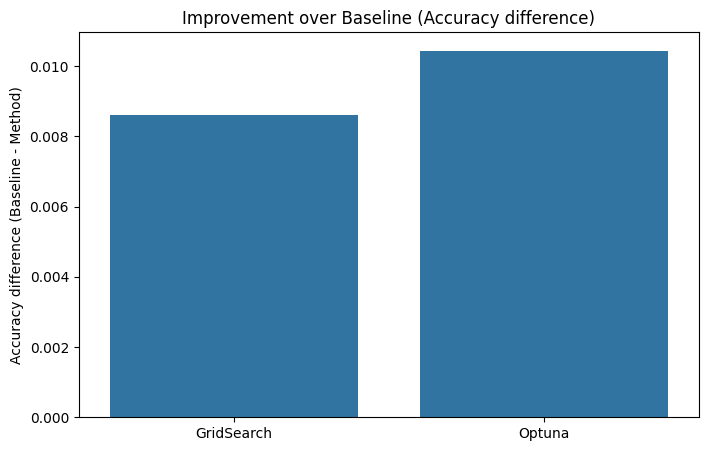

In [62]:
improvement_grid = grid_accuracy - default_accuracy
improvement_optuna = optimized_accuracy - default_accuracy


improvement_values = [improvement_grid, improvement_optuna]
methods = ["GridSearch", "Optuna"]

plt.figure(figsize=(8, 5))
sns.barplot(x=methods, y=improvement_values)
plt.title("Improvement over Baseline (Accuracy difference)")
plt.ylabel("Accuracy difference (Baseline - Method)")
plt.show()


In [63]:
results_df = pd.DataFrame({
    "Method": ["Default", "GridSearch", "Optuna"],
    "Model": ["RandomForestClassifier"] * 3,
    "Time": [default_duration, grid_duration, optuna_duration],
    "Accuracy": [default_accuracy, grid_accuracy, optimized_accuracy],
    "Best Params (GridSearch)": [np.nan, str(best_grid_params), np.nan],
    "Best Params (Optuna)": [np.nan, np.nan, str(best_optuna_params)]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

print("\n=== Results DataFrame ===")
print(results_df[["Method", "Model", "Time", "Accuracy"]])

print(" ")
print(results_df[["Best Params (GridSearch)"]])

print(" ")
print(results_df[["Best Params (Optuna)"]])


=== Results DataFrame ===
       Method                   Model         Time  Accuracy
0     Default  RandomForestClassifier    18.535616  0.858283
1  GridSearch  RandomForestClassifier   548.836014  0.866882
2      Optuna  RandomForestClassifier  5076.235051  0.868724
 
                                                                  Best Params (GridSearch)
0                                                                                      NaN
1  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
2                                                                                      NaN
 
                                                                    Best Params (Optuna)
0                                                                                    NaN
1                                                                                    NaN
2  {'n_estimators': 142, 'max_depth': 29, 'min_samples_split': 9, 'min_samples_leaf': 2}
